#  Is Sleep Really the Key?

### Data-Driven Insights into Sleep, Stress, and Productivity

---

Understanding how sleep affects productivity is a common concern for students and professionals. Many people believe that getting more sleep automatically leads to better performance, but the reality may be more complex.

This project explores the relationship between sleep duration, stress levels, and productivity using a real-world dataset.

##  Research Question

Is sleep duration the main factor driving productivity, or do other variables such as stress play a more significant role?

This analysis aims to explore whether:
- More sleep always leads to higher productivity
- Stress reduces productivity even when sleep is sufficient
- Productivity is influenced by multiple interacting factors

##  1. Dataset Overview

The dataset used in this analysis contains information about individuals' sleep habits, lifestyle factors, and health indicators.

Key variables include:

- **Sleep Duration**: Number of hours slept per night
- **Quality of Sleep**: A numerical measure used as a proxy for productivity
- **Stress Level**: Self-reported stress levels
- **Physical Activity Level**: Daily activity level
- **BMI Category**: Body mass index classification

For this study, *quality of sleep* is used as a proxy for productivity, as better sleep quality is strongly associated with improved cognitive performance and daily functioning.

In [4]:
import pandas as pd

df = pd.read_csv("data/Sleep_health_and_lifestyle_dataset.csv")

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

##  2. Relationship Between Sleep and Productivity

The first visualization examines the relationship between sleep duration and productivity.

We expect that longer sleep duration may be associated with higher productivity, but this relationship may not be strictly linear.

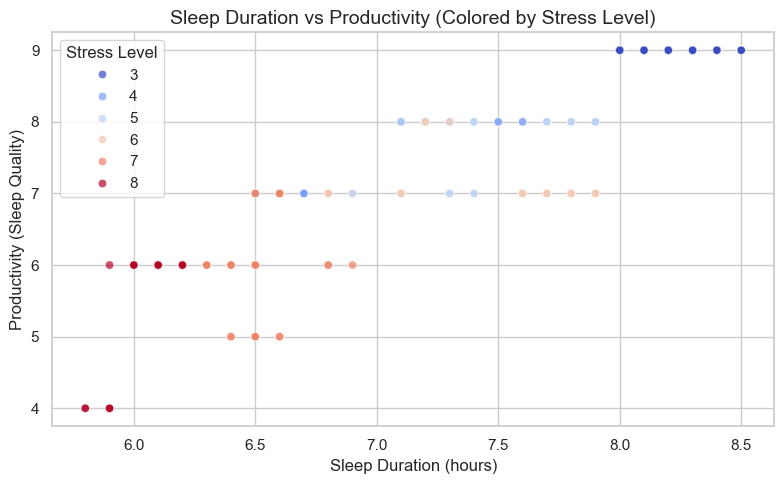

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Sleep Duration",
    y="Quality of Sleep",
    hue="Stress Level",
    palette="coolwarm",
    alpha=0.7
)

plt.title("Sleep Duration vs Productivity (Colored by Stress Level)", fontsize=14)
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Productivity (Sleep Quality)")

plt.tight_layout()
plt.savefig("figures/sleep_vs_productivity.png", dpi=300)
plt.show()

###  Interpretation

The scatter plot shows a generally positive relationship between sleep duration and productivity. However, the variation across different stress levels suggests that sleep alone does not fully explain productivity.

Individuals with higher stress levels tend to have lower productivity, even when they get sufficient sleep. This indicates that stress may act as a moderating factor in the relationship between sleep and performance.

##  3. Impact of Stress on Productivity

The second visualization focuses on how stress levels affect productivity.

Unlike sleep duration, stress is expected to have a more direct negative impact on productivity.

C:\Users\23730\AppData\Local\Temp\ipykernel_11440\2652947256.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


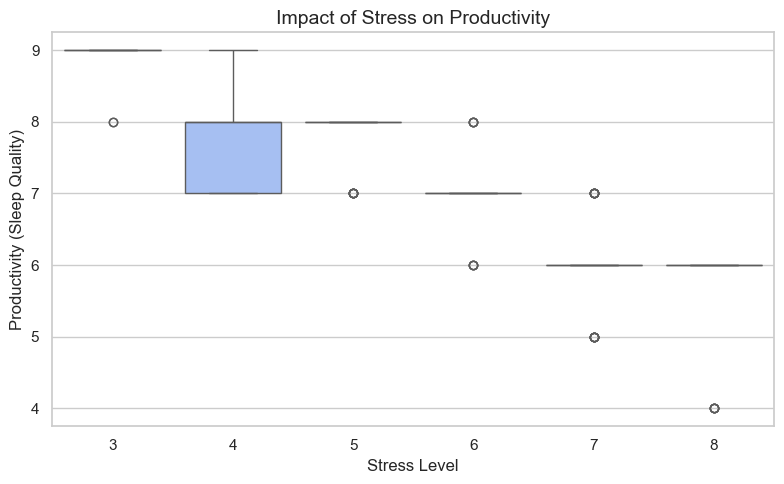

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Stress Level",
    y="Quality of Sleep",
    palette="coolwarm"
)

plt.title("Impact of Stress on Productivity", fontsize=14)
plt.xlabel("Stress Level")
plt.ylabel("Productivity (Sleep Quality)")

plt.tight_layout()
plt.savefig("figures/stress_vs_productivity.png", dpi=300)
plt.show()

### Interpretation

The results clearly show that higher stress levels are associated with lower productivity.

This suggests that stress plays a critical role in shaping performance outcomes. Even individuals who sleep well may experience reduced productivity if their stress levels are high.

Therefore, improving productivity may require not only better sleep habits but also effective stress management.

## 4. Interactive Exploration: Sleep, Stress, and Productivity

To better understand the relationship between sleep and productivity, an interactive visualization is provided below.

This chart allows users to:
- Hover over individual data points to see detailed information
- Explore how productivity varies across different stress levels
- Observe how multiple factors interact simultaneously

Unlike static charts, this interactive view enables deeper exploration of the data and reveals patterns that may not be immediately visible.

In [12]:
import plotly.express as px

fig = px.scatter(
    df,
    x="Sleep Duration",
    y="Quality of Sleep",
    color="Stress Level",
    size="Physical Activity Level",
    hover_data=["Age", "Occupation"],
    title="Interactive: Sleep vs Productivity (Colored by Stress)"
)
fig.write_html("figures/interactive_plot.html")
fig.show()

## 5. Linked View: How Stress Changes the Sleep–Productivity Relationship

To further explore the role of stress, the dataset is divided into different stress categories (Low, Medium, High).

This visualization presents a linked view where the relationship between sleep and productivity is shown separately for each stress group.

By comparing these panels side by side, we can better understand how stress modifies the impact of sleep on productivity.

In [13]:
df["Stress Category"] = pd.cut(
    df["Stress Level"],
    bins=[0, 4, 7, 10],
    labels=["Low", "Medium", "High"]
)

In [15]:
fig = px.scatter(
    df,
    x="Sleep Duration",
    y="Quality of Sleep",
    color="Stress Category",
    facet_col="Stress Category",
    title="Linked View: Sleep vs Productivity by Stress Level"
)
fig.write_html("figures/linked_view.html")
fig.show()

## 6. Physical Activity and Productivity

In addition to sleep and stress, physical activity may also influence productivity.

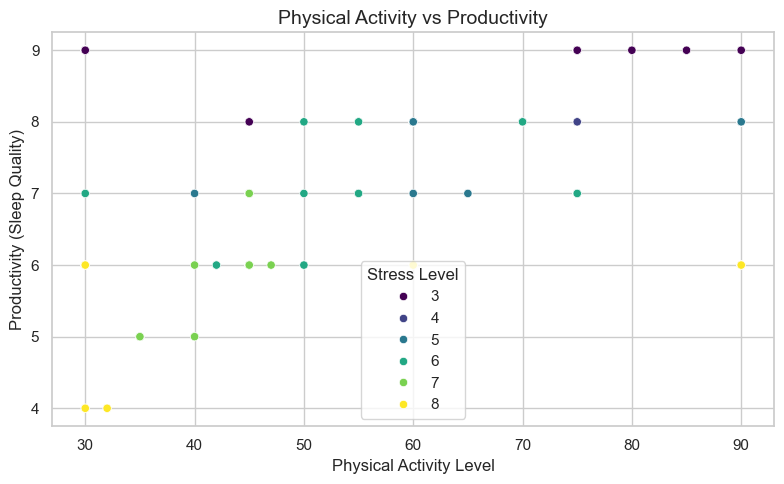

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Physical Activity Level",
    y="Quality of Sleep",
    hue="Stress Level",
    palette="viridis"
)

plt.title("Physical Activity vs Productivity", fontsize=14)
plt.xlabel("Physical Activity Level")
plt.ylabel("Productivity (Sleep Quality)")

plt.tight_layout()
plt.savefig("figures/activity_vs_productivity.png", dpi=300)
plt.show()

## 7. Correlation Between Variables

To better understand the relationships between key variables, a correlation heatmap is presented below.

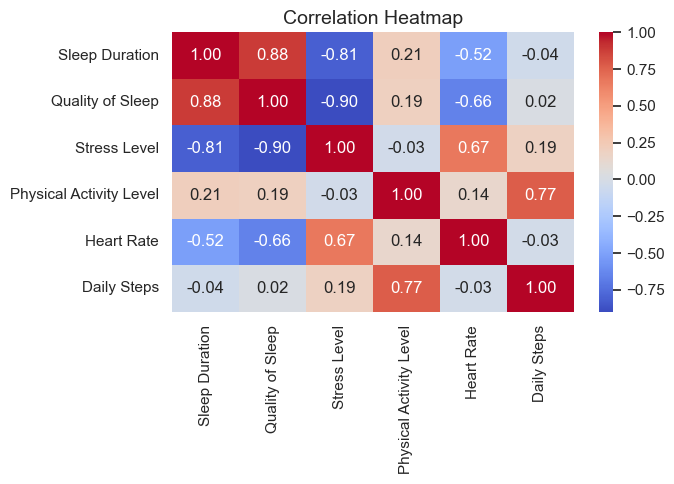

In [ ]:
import numpy as np

numeric_df = df[[
    "Sleep Duration",
    "Quality of Sleep",
    "Stress Level",
    "Physical Activity Level",
    "Heart Rate",
    "Daily Steps"
]]

corr = numeric_df.corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300)
plt.show()

## 🔍 Overall Insight

Combining both the interactive and linked visualizations, a clear pattern emerges:

Sleep alone is not sufficient to guarantee high productivity. While it plays an important role, its benefits are significantly reduced under high stress conditions.

This highlights the importance of a balanced approach to well-being, where both adequate sleep and effective stress management are essential for optimal performance.